# Сжатие языковой модели

Выполнил студент Андрющенко К.С.

## Порядок сдачи домашнего

Под каждое домашнее вы создаете отдельную ветку куда вносите все изменения в рамках домашнего. Как только домашнее готово - создаете пулл реквест (обратите внимание что в пулл реквесте должны быть отражены все изменения в рамках домашнего). Ревьювера назначаете из таблицы - https://docs.google.com/spreadsheets/d/1vK6IgEqaqXniUJAQOOspiL_tx3EYTSXW1cUrMHAZFr8/edit?gid=0#gid=0
Перед сдачей проверьте код, напишите тесты. Не забудьте про PEP8, например, с помощью flake8. Задание нужно делать в jupyter notebook.

**Дедлайн - 17 октбяря 10:00**

В этом домашнем задании вам предстоит изучить и реализовать комбинированный алгоритм для сжатия матриц весов языковой модели, который включает три этапа: 
- **Квантизацию**
- **Кодирование Хаффмана**
- **Бит-паккинг**
- **Запись и чтение в файл**

Вам также необходимо будет реализовать обратную процедуру расжатия для восстановления матрицы до её исходного состояния. Пакетом `numpy` пользовать нельзя.

Для начала сгенерируем нашу матрицу весов. Реализуйте функцию `generate_normal_weights_matrix`, которая будет генерировать матрицу случайных весов, где веса распределены нормально. Вам понадобится функция `random.gauss` для генерации случайных чисел из нормального распределения:

In [96]:
import random

mean = 0.0
stddev = 0.1
random.gauss(mean, stddev)

-0.0171874220103806

```python
weights_matrix = generate_normal_weights_matrix(5, 5)
for row in weights_matrix:
    print(row)
[0.3000485326712691, 0.25965299191334695, -0.06755153631842248, 0.13020487844655038, 0.1143769419370928]
[0.04287032494033407, 0.37860865986969466, -0.21154587156719093, 0.02538857794887883, 0.358874552698265]
[-0.12730102686770312, -0.09250783210681686, -0.31943991155969786, -0.12649930568136855, -0.133368865014227]
[-0.001125940850390421, 0.08131363950833258, -0.12099869191945688, 0.14554258117597563, 0.157276907472140]
[-0.07352639207896368, 0.013629438616873364, -0.11502982664385775, 0.042140678513802377, 0.0980238501942050]
```

In [97]:
print(random.gauss(mean, stddev))

-0.12829947687295515


Синтаксис генератора списков ```[expression for item in iterable if condition]```

In [98]:
def generate_normal_weights_matrix(rows, cols, mean=0.0, stddev=0.1):
    result = [[random.gauss(mean, stddev) for _ in range(cols)] for _ in range(rows)]
    return result

Выполним проверку

In [99]:
weights_matrix = generate_normal_weights_matrix(5, 5)
for row in weights_matrix:
    print(row)

[0.08931360962244794, 0.14989195079293224, -0.03135779994832022, 0.2473393557968756, 0.12533760800845234]
[-0.0859175511319965, 0.004611200391341958, -0.1074376724405468, -0.08147642243013276, 0.11952460247859234]
[0.02329053877869366, 0.09948728213447904, 0.09896999073655326, 0.11054537492032408, -0.07068615574594478]
[-0.03675943907309171, -0.052334133366030024, 0.055565157487295305, 0.11174215401934913, -0.016830079849041935]
[-0.047751030647191176, 0.08540568978406839, -0.003988321664979032, -0.05082578120672592, -0.06719870161892187]


Для упрощения работы переведем двух мерный массив в одномерный.

In [100]:
weights_matrix = generate_normal_weights_matrix(100, 100, mean, stddev)

In [101]:
weights = [weight for row in weights_matrix for weight in row]

Проверим, что у нас получилось.

Установим необходимые библиотеки, в том числе numpy, так как это предусмотренно автором для данного задания.

In [102]:
%pip install matplotlib 


[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
%pip install scipy


[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [104]:
import numpy as np

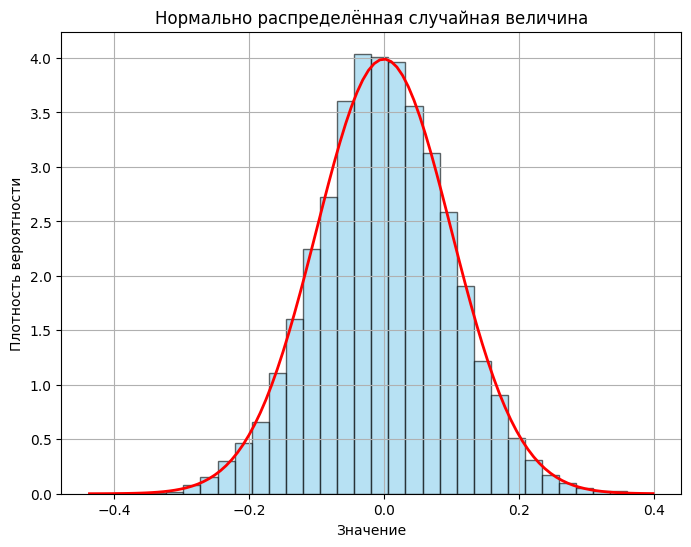

In [105]:
import matplotlib.pyplot as plt
import scipy.stats as stats
plt.figure(figsize=(8, 6))
count, bins, ignored = plt.hist(weights, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Добавление кривой плотности вероятности
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, stddev)  # Вычисление плотности вероятности
plt.plot(x, p, 'r', linewidth=2)

# Настройки графика
plt.title("Нормально распределённая случайная величина")
plt.xlabel("Значение")
plt.ylabel("Плотность вероятности")
plt.grid(True)

# Отображение графика
plt.show()

Приступим к сжатию этой матрицы!

## Квантизация

**Квантизация** — это процесс преобразования данных с высокой точностью (например, с 32-битного представления) в данные с более низкой точностью (например, 8-битное представление) для уменьшения объёма памяти и вычислительных ресурсов. В контексте машинного обучения, квантизация чаще всего применяется к весам нейронных сетей и их активациям для уменьшения размера модели и ускорения работы, особенно при выполнении инференса на мобильных устройствах и встраиваемых системах.


### Цели квантизации:

1.	**Уменьшение объёма памяти:** Квантизация позволяет сократить объём памяти, занимаемый весами и другими параметрами модели, путём представления чисел с меньшей разрядностью.
2.	**Ускорение вычислений:** С помощью квантизации можно использовать специальные процессоры и ускорители (например, процессоры с поддержкой 8-битных вычислений), что увеличивает производительность.
3.	**Снижение энергопотребления:** Более короткие представления данных позволяют сократить энергопотребление при выполнении операций.

### Как работает квантизация?

Квантизация заключается в преобразовании значений с высокой точностью (например, числа с плавающей точкой) в числа с меньшей точностью (например, целые числа). Существует несколько методов квантизации:

1.	**Униформная (равномерная) квантизация:** Простая и часто используемая техника, когда диапазон значений разделяется на равные интервалы (кванты), и каждое значение округляется до ближайшего значения из этого интервала.
2.	**Неравномерная квантизация:** Применяется, когда диапазон значений распределён неравномерно, и поэтому используются интервалы с разной шириной.
3.	**Квантизация во время обучения (quantization-aware training):** Модель обучается с учётом того, что её веса будут квантизированы. Это позволяет лучше подготовить модель к работе в условиях низкой точности.
4.	**Квантизация после обучения (post-training quantization):** Модель сначала обучается с полной точностью, а затем веса и активации квантизируются.

В данном домашнем задании мы рассмотри наиболее простой вариант - **равномерная квантизация**.

### Пример униформной квантизации

Предположим, у нас есть матрица весов, представленная в виде чисел с плавающей точкой, и мы хотим сократить количество бит, используемых для хранения этих значений.

#### Шаг 1: Определение диапазона значений

Для начала определим минимальное и максимальное значение весов, чтобы определить диапазон:

In [106]:
min_value = min(weights)
max_value = max(weights)

print(f"Минимальное значение: {min_value}")
print(f"Максимальное значение: {max_value}")

Минимальное значение: -0.3987099151199897
Максимальное значение: 0.3612341891853216


#### Шаг 2: Определение шага квантизации

Теперь мы определим шаг квантизации, который будет разделять диапазон на равные интервалы. Предположим, что мы хотим использовать 8-битное представление. Это даёт нам $256$ различных значений (так как $8$ бит позволяют хранить $2^8 = 256$ различных чисел).

Шаг квантизации можно вычислить как:


$$\text{step} = \frac{\max - \min}{2^8 - 1}$$


In [107]:
num_levels = 256  # Для 8 бит
step = (max_value - min_value) / (num_levels - 1)
print(f"Шаг квантизации: {step}")

Шаг квантизации: 0.002980172958060044


#### Шаг 3: Применение квантизации

Теперь мы можем преобразовать каждое значение в его ближайший квантизированный уровень:


${quantized value} = \text{round} \left( \frac{\text{value} - \min}{\text{step}} \right)$


In [108]:
quantized_weights = [round((weight - min_value) / step) for weight in weights]

print("Квантизированные веса:")
print(set(quantized_weights))

Квантизированные веса:
{0, 2, 13, 23, 29, 30, 32, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 235, 236, 237, 2

#### Шаг 4: Обратное преобразование (деквантизация)

Чтобы восстановить оригинальные значения весов, необходимо преобразовать квантизированные значения обратно в их исходный диапазон:


$$recovered value = {quantized value} \times \text{step} + \min$$


In [109]:
recovered_weights = [quantized_weight * step + min_value for quantized_weight in quantized_weights]

print("Восстановленные веса:")
print(recovered_weights[:5])

Восстановленные веса:
[-0.09473227339786522, 0.018514299008416446, 0.060236720421257106, 0.02447464492453655, 0.021494471966476525]


Посчитаем максимальную ошибку

In [110]:
max([abs(w - rw) for w, rw in zip(weights, recovered_weights)])

0.0014899742213460576

На практике намного удобнее, когда мы можем контролировать ошибку, поэтому реализуйте методы квантизации и деквантизации, у которых будет параметр максимальной возможной ошибки между значениями для задания `step`.

Параметр максимальной возможной ошибки между значениями для задания ```step``` $step = 2 * max error$

In [111]:
def quantize_weights(weights, max_error):
    # минимальное значения весов
    min_value = min(weights)
    # max_value = max(weights)
    # шаг квантизации
    step = 2 * max_error
    # преобразование в ближайщий квант-ный уровень
    quantized_weights = [round((weight - min_value) / step) for weight in weights]
    return quantized_weights, step, min_value


def dequantize_weights(quantized_weights, step, min_value):
    recovered_weights = [quantized_weight * step + min_value for quantized_weight in quantized_weights]
    return recovered_weights

In [144]:
max_error = 0.01
quantized_weights, step, min_value = quantize_weights(weights, max_error)
recovered_weights = dequantize_weights(quantized_weights, step, min_value)

Проверим получившуюся максимальную ошибку

In [145]:
max([abs(w - rw) for w, rw in zip(weights, recovered_weights)])

0.009999668091041775

## Кодирование Хаффмана

**Кодирование Хаффмана** — это алгоритм сжатия данных, который используется для минимизации количества бит, необходимых для представления данных. Алгоритм Хаффмана является типом префиксного кодирования, где каждому символу данных назначается уникальная двоичная строка (код), и никакой код не является префиксом другого кода.

Этот метод особенно полезен, когда некоторые символы встречаются чаще других. Хаффмановское кодирование назначает более короткие коды для часто встречающихся символов и более длинные коды для редких символов, что позволяет сжимать данные без потерь.

Основные характеристики кодирования Хаффмана:

- **Префиксный код:** никакой код не является префиксом другого кода, что позволяет однозначно декодировать последовательность.
- **Оптимальность:** алгоритм Хаффмана даёт минимальную длину кодов для символов при известной частоте их появления.
- **Дерево Хаффмана:** строится на основе частот символов, где часто встречающиеся символы находятся ближе к корню дерева.


### Этапы работы алгоритма Хаффмана:

1.	**Подсчёт частот:** На первом шаге подсчитывается, как часто каждый символ встречается в данных.
2.	**Построение дерева Хаффмана:** Используя частоты символов, строится бинарное дерево. Символы с меньшими частотами располагаются дальше от корня дерева, а символы с более высокими частотами — ближе.
3.	**Назначение кодов:** Проходя от корня дерева к каждому листу (символу), алгоритм назначает каждому символу код: левой ветви присваивается “0”, а правой ветви — “1”. Таким образом, для каждого символа формируется уникальная двоичная строка.
4.	**Сжатие данных:** После того как к каждому символу присвоен код, данные можно сжать, заменив символы на соответствующие двоичные коды.
5.	**Декодирование:** Для восстановления исходных данных декодирование выполняется путём чтения двоичной строки и перемещения по дереву Хаффмана от корня до символа, который закодирован.

### Пример работы алгоритма Хаффмана

Рассмотрим, как кодирование Хаффмана может быть применено к строке “ABRACADABRA”.

**1.	Частоты символов:**
Подсчитаем частоты каждого символа в строке:
```python
A: 5
B: 2
R: 2
C: 1
D: 1
```

**2. Построение дерева Хаффмана:**
- Начнем с того, что каждый символ представляется в виде узла дерева с весом, равным частоте появления символа.
- На каждом шаге выбираются два узла с наименьшими частотами и объединяются в новый узел, вес которого равен сумме частот двух выбранных узлов. Этот процесс повторяется до тех пор, пока не будет построено одно дерево.

Строим дерево Хаффмана:
```python
Шаг 1:   C:1  D:1 -> 2 (левое поддерево: C, правое поддерево: D)
Шаг 2:   B:2  R:2 -> 4 (левое поддерево: B, правое поддерево: R)
Шаг 3:   2 (CD)  4 (BR) -> 6
Шаг 4:   A:5  6 (CD, BR) -> 11
```

Окончательное дерево Хаффмана выглядит следующим образом:

```python
      11
     /  \
    A    6
        /  \
      CD    BR
      / \   / \
     C   D B   R
```

**3.	Назначение кодов:**
Теперь присвоим каждому символу код, начиная от корня дерева:
- A: 0
- C: 100
- D: 101
- B: 110
- R: 111

**4. Сжатие строки:**
Используя полученные коды, мы можем закодировать строку “ABRACADABRA”:
```python
A -> 0
B -> 110
R -> 111
A -> 0
C -> 100
A -> 0
D -> 101
A -> 0
B -> 110
R -> 111
A -> 0
```

Закодированная строка: 0110111001000101101110

Реализуйте методы `huffman_encode` и `huffman_decode` для кодирования и декодирования с помощью алгоритма Хаффмана.

In [114]:
from collections import Counter

In [115]:
from collections import namedtuple

In [116]:
import heapq

In [117]:
Node = namedtuple("Node", ["left", "right"])
Leaf = namedtuple("Leaf", ["naem"])

In [118]:
def walk(root, code, pref):
    if isinstance(root, Node):
        # по левой ветви 0
        walk(root.left, code, pref + "0")
        # по правой ветви 1
        walk(root.right, code, pref + "1")
    else:
        if pref:
            code[root.naem] = pref
        else: 
            code[root.naem] = "0"
    return root, code

In [139]:
def huffman_encode(weights):
    huff_dict = {}
    # подсчет каждого символа
    elements = Counter(weights)
    # ({'A': 5, 'B': 2, 'R': 2, 'C': 1, 'D': 1})
    # взятие элемента с минимальной частотой пока элементов более одного (не корень)
    sorted_elements = [(frq, i, Leaf(el)) for i, (el, frq) in enumerate(elements.items())]
    # у каждого листа есть частота, номер, имя
    # (5, 0, Leaf(naem='A')), (5, 1, Leaf(naem='A'))
    #print(sorted_elements)
    # преобразовать список x в кучу на месте за линейное время
    heapq.heapify(sorted_elements)
    # номер листа в куче на каждой итерации
    num = len(sorted_elements)
    while len(sorted_elements) > 1:
        # Извлечь и вернуть наименьший элемент из кучи
        frq1, _, left = heapq.heappop(sorted_elements)
        frq2, _, right = heapq.heappop(sorted_elements)
        # Помещаем элемент значения в кучу
        # складываем частоты символов и имена в узле
        heapq.heappush(sorted_elements, (frq1 + frq2, num, Node(left, right)))
        num += 1
    if sorted_elements:
        # корень 
        [(_freq, _count, root)] = sorted_elements
        # построение кодов для узла и листа
        root, huff_dict = walk(root, huff_dict, "")
        # собираем закодированное сообщение
    encoded_data = ""
    for symbol in weights:
        encoded_data += huff_dict[symbol]
    print(huff_dict)
    return encoded_data, huff_dict


def huffman_decode(encoded_data, huff_dict):
    pointer = 0
    decoded_data = []
    while pointer < len(encoded_data):
        for ch in huff_dict.keys():
            if encoded_data.startswith(huff_dict[ch], pointer):
                decoded_data.append(ch)
                pointer += len(huff_dict[ch])
                break
        else:
            return decoded_data
    return decoded_data


data = "ABRACADABRA"
encoded_data, huff_dict = huffman_encode(data)
print(f"Закодированные данные: {encoded_data}")
# Закодированные данные: 01101001110011110110100

decoded_data = huffman_decode(encoded_data, huff_dict)
print(f"Декодированные данные: {decoded_data}")
# Декодированные данные: ABRACADABRA

{'A': '0', 'C': '100', 'D': '101', 'B': '110', 'R': '111'}
Закодированные данные: 01101110100010101101110
Декодированные данные: ['A', 'B', 'R', 'A', 'C', 'A', 'D', 'A', 'B', 'R', 'A']


Как можно было сделать иначе:  
*Поскольку именованные кортежи построены на обычных классах, то можно добавить методы (а именно walk) в класс, унаследованный от именованного кортежа.*

Тестирование  
1. Один символ
2. Пустая строка
3. Строка из повторяющихся символов   

In [158]:
data = "A"
encoded_data, huff_dict = huffman_encode(data)
print(f"Закодированные данные: {encoded_data}")
# Закодированные данные: 01101001110011110110100

decoded_data = huffman_decode(encoded_data, huff_dict)
print(f"Декодированные данные: {decoded_data}")

{'A': '0'}
Закодированные данные: 0
Декодированные данные: ['A']


In [160]:
data = ""
encoded_data, huff_dict = huffman_encode(data)
print(f"Закодированные данные: {encoded_data}")
# Закодированные данные: 01101001110011110110100

decoded_data = huffman_decode(encoded_data, huff_dict)
print(f"Декодированные данные: {decoded_data}")

{}
Закодированные данные: 
Декодированные данные: []


In [162]:
data = "AAA"
encoded_data, huff_dict = huffman_encode(data)
print(f"Закодированные данные: {encoded_data}")
# Закодированные данные: 01101001110011110110100

decoded_data = huffman_decode(encoded_data, huff_dict)
print(f"Декодированные данные: {decoded_data}")

{'A': '0'}
Закодированные данные: 000
Декодированные данные: ['A', 'A', 'A']


#### Посчитаем Хаффмана на наших квантизированных весах

In [146]:
encoded_data, huffman_dict = huffman_encode(quantized_weights)

{26: '0000', 28: '00010', 12: '00011', 25: '0010', 15: '0011', 10: '010000', 31: '0100010', 9: '0100011', 27: '01001', 16: '0101', 8: '0110000', 35: '011000100', 36: '01100010100', 0: '011000101010', 38: '011000101011', 5: '0110001011', 4: '011000110000', 3: '0110001100010', 2: '0110001100011', 37: '01100011001', 34: '0110001101', 6: '011000111', 11: '011001', 13: '01101', 24: '0111', 23: '1000', 29: '100100', 30: '1001010', 32: '10010110', 7: '100101110', 33: '100101111', 14: '10011', 17: '1010', 22: '1011', 21: '1100', 19: '1101', 18: '1110', 20: '1111'}


## Бит пакинг

**Бит-паккинг (bit-packing)** — это техника сжатия данных, при которой несколько чисел или символов, представленных в виде бит, “упаковываются” в одно или несколько целых чисел (байтов или слов) с целью минимизировать занимаемую память. Этот метод особенно эффективен, если числа или коды занимают меньше бит, чем стандартный размер ячейки памяти (например, 8 бит для байта или 32 бит для целого числа).


### Основная идея:

Если каждая единица данных (например, число или символ) требует меньше бит, чем стандартная ячейка памяти, можно “упаковать” несколько таких единиц данных в одну ячейку, чтобы избежать потерь памяти на неиспользуемые биты. Это позволяет эффективно использовать пространство памяти и уменьшить общий объём данных.

### Пример использования бит-паккинга после кодирования Хаффмана

После кодирования Хаффмана символы данных преобразуются в коды разной длины (в битах). Например, для часто встречающихся символов коды будут короткими (например, 2 или 3 бита), а для редких символов — длинными (например, 6 или 7 бит). Однако стандартные структуры данных Python (например, массивы байтов) используют 8-битные ячейки памяти, что может привести к неэффективному использованию памяти, если не применить бит-паккинг.

### Почему бит-паккинг полезен после кодирования Хаффмана?

После кодирования Хаффмана мы получаем строку из 0 и 1 разной длины для каждого символа. Например:
```python
A -> 0
B -> 110
C -> 1001
```

Закодированная строка после Хаффмана может выглядеть так: 011011001. Если мы будем хранить эту строку побитно в стандартных байтах, это может занять больше места, чем нужно, так как каждый символ по умолчанию занимает 8 бит. Однако с помощью бит-паккинга можно эффективно “упаковать” эти коды в минимально возможное количество байтов.

### Пример

Предположим, у нас есть коды:

```python
A -> 0 (1 бит)
B -> 110 (3 бита)
C -> 1001 (4 бита)
```

После кодирования строки “AABAC”, мы получаем последовательность бит: 0110110011001. Данная строка может быть запакована в 2 байта:
- В первом байте хранится значение 01101101 (первые 8 бит).
- Во втором байте хранится значение 10011000 (оставшиеся 5 бит и заполненные нулями).

Реализуйте функцию `bit_packing`, которая упаковывает входную битовую строку в набор байт.

```python
encoded_data = "0110110011001"
packed_data = bit_packing(encoded_data)

print(f"Упакованные данные: {packed_data}")
Упакованные данные: b'l\xc8'
print(f"Длина упакованных данных: {len(packed_data)} байт")
Длина упакованных данных: 2 байт
```

Для перевода в двоичную систему ```int(bit_string, 2)```

Для получения последовательности байт ```int.to_bytes(length=1, byteorder='big', *, signed=False) ```

In [121]:
def bit_packing(bit_string):
    len_bit_string = len(bit_string)
    # допишем нули в конец
    if len_bit_string % 8 != 0: 
        bit_string += '0' * (8 - len_bit_string % 8)
    # длинна bit_string изменилась
    bit_string = int(bit_string, 2).to_bytes(len(bit_string) // 8, 'big')
    return bit_string

Тестирование

In [122]:
encoded_data = "0110110011001"
packed_data = bit_packing(encoded_data)

print(f"Упакованные данные: {packed_data}")
print(f"Длина упакованных данных: {len(packed_data)} байт")

Упакованные данные: b'l\xc8'
Длина упакованных данных: 2 байт


Реализуйте функцию `bit_unpacking`, которая распаковывет набор байт в битовую строку.
```python
unpacked_data = bit_unpacking(packed_data)
print(f"Распакованные данные: {unpacked_data}")
Распакованные данные: 0110110011001000
```

```int.from_bytes(bytes, byteorder='big', *, signed=False)```
Возвращает целое число, представленное заданным массивом байтов

In [123]:
def bit_unpacking(packed_data):
    num = int.from_bytes(packed_data, "big")
    # двоичный формат
    unpaked_string = '{0:b}'.format(num)
    # дописываем нули в начало
    if len(unpaked_string) % 8 != 0: 
        unpaked_string = '0' * (8 - len(unpaked_string) % 8) + unpaked_string
    return unpaked_string

In [124]:
unpacked_data = bit_unpacking(packed_data)
print(f"Распакованные данные: {unpacked_data}")

Распакованные данные: 0110110011001000


#### Теперь запакуем закодированные данные

In [147]:
packed_data = bit_packing(encoded_data)

## Запись и чтение в файл

Работа с файлами в бинарном режиме в Python позволяет читать и записывать байты вместо текста. Это полезно для работы с бинарными данными, такими как изображения, аудиофайлы, видео, архивы и другие типы файлов, где данные представлены не в текстовом виде, а в виде байтов.

### Открытие файлов в бинарном режиме

Для открытия файла в бинарном режиме используются следующие режимы:

- 'rb' — открыть файл для чтения в бинарном режиме.
- 'wb' — открыть файл для записи в бинарном режиме (при этом файл перезаписывается).
- 'ab' — открыть файл для добавления в бинарном режиме.
- 'rb+' или 'wb+' — открыть файл для чтения и записи в бинарном режиме.

### Кодирование и декодирование
Когда вы открываете файл в бинарном режиме ('wb' или 'rb'), данные в этом файле хранятся и читаются в виде байтов. Символы в строках Python (тип str) не могут быть напрямую записаны в файл, потому что они хранятся в формате Unicode (например, UTF-8, UTF-16), а файлы оперируют байтовыми данными.

- `encode()`: Преобразует строку Unicode в байты с использованием заданной кодировки (по умолчанию обычно UTF-8). Это нужно для записи текста в файл.
- `decode()`: Преобразует байты обратно в строку Unicode, чтобы можно было прочитать текст из файла.

Обратите внимание, что `packed_data` уже байты и их можно без кодирования и декодирования записывать в файл.


### Пример 1: Запись в файл в бинарном режиме

In [126]:
with open('output.bin', 'wb') as f:
    f.write(f"{step:.6f}\n".encode())

### Пример 2: Чтение файла в бинарном режиме

In [127]:
# Открываем файл для чтения в бинарном режиме
with open('output.bin', 'rb') as f:
    step = float(f.readline().strip())
    print(step)

0.02


Реализуйте функцию `write_to_file` для сохранения матрицы в сжатом формате

Для удобства будем записывть данные в следующем виде:  
step  
min_value   
Длина huffman_dict (чтобы было удобно читать)  
huffman_dict  
packed_data (все от конца huffman_dict и до конца файла)  

In [128]:
def write_to_file(filename, packed_data, huffman_dict, step, min_value):
    # в бинарном режиме
    with open(filename, 'wb') as f:
        # записываем данные файл
        f.write(f"{step:.6f}\n".encode())
        f.write(f"{min_value:.6f}\n".encode())
        f.write(f"{len(huffman_dict)}\n".encode())
        for k, v in huffman_dict.items():
            f.write(f"{k}:{v}\n".encode())
        f.write(packed_data)

#### Сохраним в файл сжатую матрицу и параметры для восстановления

In [129]:
compresed_filename = 'compressed_data.bin'

In [148]:
write_to_file(compresed_filename, packed_data, huffman_dict, step, min_value)

Реализуйте функцию `read_from_file` для чтения матрицы и сохраненной информации необходимой для восстановления матрицы.

In [131]:
def read_from_file(filename):
    # для чтения
    with open(filename, 'rb') as f:
        # во всех строках удалим пробелы
        # первая строка
        step = float(f.readline().strip())
        # вторая строка
        min_value = float(f.readline().strip())
        # третья строка
        huffman_len = int(f.readline().strip())
        huffman_dict = dict()
        # huffman_len строк прочитать
        for _ in range(huffman_len):
            k, v = f.readline().strip().decode().split(':')
            huffman_dict[int(k)] = str(v)
        packed_data = f.read()
    return packed_data, huffman_dict, step, min_value

#### Прочитаем файл и восстановим данные

In [149]:
packed_data, huffman_dict, step, min_value = read_from_file(compresed_filename)
print(packed_data)
unpacked_bits = bit_unpacking(packed_data)
# print(unpacked_bits, huffman_dict)
decoded_weights = huffman_decode(unpacked_bits, huffman_dict)
recovered_weights = dequantize_weights(decoded_weights, step, min_value)
recovered_weights

b'<\x8c\xcd\xd0Mu\x7f\xc9\xb3\x9e/X\xd6K\x96\x8e\xca\x86\xa0\xb6\x02\xe2\xf9\xec\x81\xda\xb1\xd2?\xcf\xf4\xf6/\x12S8\xab\xf6\x8a\x89\x01a\xb8\\\x86\x97\x81\xdd\xa7U\x15A\x03a\xa7gGX\xf6\xf1\x971I\x0fg\x9a\xf7x/!,\xba\x0e\x9d{3\xdeL\xddW\xef\x93l\xd6\xb6@\xfa\x96\xed\xc5\x8d~>-1>\x87\xa7\x0f\x8eU\xe1\xc6\x90E%^hJe~\x96{\xb2<s9\xdd9\xcb}\xf9~A\xc2z5\xfe\xafyv\xad\x95}x\xbd\xc4\xc3\xd7$\xe39\xe5\x1d\xb3Q\xaf\x8e\xf9\xaf<\xc8\x17\xd1]\x94O\x15\x84uS\x0c\x8d,C\xd1\x04\x8f\x062\xde\xa0\xd9\xe5\xf7\xff{,i\xa2\xb9\xcf\r_\xf4\xd7\xa7K\xfc\x82\xfa\x1d$~\xd4\x1f\x97\x9d\xbeV\x14\xb3\x97\xd4V\x9e\xc7\xfag\x15\x16`\xdc[\x19\xda\xf8\xdd\xab\x9b\x9e\xa9\x1b\xe2\xee\xf1\'\x876c\xf6\xdc\xde\xaa{\xdd\xd2\xa3j\xeb[Z\x88\xff\x06\xffd\xa6\xe0\x07\xd6(}\x1a\x9d\xba\xdb\r\xc9\xb7\x8es\xc4\xb4\xabe\xb9xW\x95.\x94/\xfb\x99\xd7\x9d\xd4\xbe:*\xb3\xb0\xb3!\xaf\xb0\xb9\xcd\x1d4\xbd\xdaC\xcb\xeb\xa6\xf4V\x83s\xf1*\xddC\xc7%\xa3\xcf\xbc\xbeFT\x06\xa5\x8bu\xce\xbcp\x0b\xf3l\xd6\xdc5\xbcI_oV\xf8\xdfQ\x83N\x8c\xb4\xaf\

[-0.09871000000000002,
 0.021289999999999976,
 0.06129000000000001,
 0.021289999999999976,
 0.021289999999999976,
 -0.018710000000000004,
 -0.018710000000000004,
 0.12129000000000001,
 0.14129000000000003,
 -0.058709999999999984,
 -0.03871000000000002,
 -0.058709999999999984,
 0.0012900000000000134,
 0.0012900000000000134,
 0.18128999999999995,
 -0.018710000000000004,
 -0.11870999999999998,
 -0.11870999999999998,
 0.021289999999999976,
 -0.07871,
 -0.03871000000000002,
 0.04128999999999999,
 -0.15871000000000002,
 -0.07871,
 0.18128999999999995,
 0.04128999999999999,
 0.24129,
 0.06129000000000001,
 -0.03871000000000002,
 0.021289999999999976,
 -0.058709999999999984,
 0.06129000000000001,
 -0.13871,
 -0.19871,
 -0.07871,
 0.04128999999999999,
 0.12129000000000001,
 0.16129000000000004,
 -0.03871000000000002,
 0.10128999999999999,
 0.0012900000000000134,
 -0.11870999999999998,
 -0.018710000000000004,
 0.18128999999999995,
 0.12129000000000001,
 -0.03871000000000002,
 -0.0187100000000000

#### Посчитаем максимальную ошибку в полученных данных (во время квантизации мы теряли часть данных)

In [150]:
max([abs(w - rw) for w, rw in zip(weights, recovered_weights)])
# 0.009999668091041775

0.009999583211031476

#### Теперь посчитаем сколько весит сохраненные данные:

In [151]:
def get_size(filename):
    return os.stat(filename).st_size / (1024 * 1024)

In [152]:
import os
print(f'Размер файла в мегабайтах {get_size(compresed_filename)}')

Размер файла в мегабайтах 0.005641937255859375


Воспользуемся пакетом `struct` для упаковывания флотов в бинарный формат для оригинальных весов.

In [156]:
import struct
original_filename = 'original_data.bin'

with open(original_filename, 'wb') as f:
    for number in weights:
        packed_data = struct.pack('f', number)
        f.write(packed_data)

In [157]:
file_stats = os.stat(original_filename)
print(f'Размер файла в мегабайтах {get_size(original_filename)}')

Размер файла в мегабайтах 0.03814697265625


# Поздравляю, языковые модели сжимать мы теперь умееем!